<a href="https://colab.research.google.com/github/Dania-Yasir/flyrak-project/blob/main/work/notebooks/w05_repeated_balanced_grouped_validation%D8%AF%D9%85%D8%AC_%D9%86%D8%AA%D9%88%D8%A8%D9%88%D9%83%D9%8A%D9%86.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone Validation Experiment — Repeated Balanced Grouped Validation

## Is the fold-to-fold volatility real client heterogeneity, or one unlucky partition?

This notebook is a **sensitivity experiment** built from the selected balanced-client capstone notebook.

### Why this experiment exists

Two earlier validation designs told slightly different stories:

- The older robustness notebook used ordinary grouped folds. Its outer test folds could contain very different numbers of clients (for example **1 / 1 / 8 / 11 / 13**).
- The selected notebook fixed that design issue with balanced client folds (about **7 / 7 / 7 / 7 / 6**), but one balanced partition still showed substantial fold-to-fold variation.

So the question is now narrower:

> **If we repeat the balanced, client-disjoint validation with many different valid client partitions, does the average model performance remain stable?**

If the **repeat means stay fairly stable** while individual folds still swing, the main issue is client heterogeneity.

If the **repeat means themselves move a lot**, then the headline performance estimate is sensitive to which clients land together.

### Important interpretation

This is **not a new independent test set** and it is **not a formal confidence interval**.  
The same March cohort is reused. This notebook is a robustness / sensitivity analysis.

### What stays fixed

- Same March 1–15 feature boundary.
- Same March 16–31 outcome.
- Same leakage guard.
- Same Full-Signal feature set.
- Same fixed Logistic Regression and Random Forest settings.
- Same Momentum-only baseline.
- Same Precision@100 definition.

Only the **balanced client partition** changes across repeats.


In [1]:
%pip install -q duckdb huggingface_hub pandas numpy scikit-learn matplotlib

In [2]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

from getpass import getpass

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn

from IPython.display import display
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import GroupKFold, StratifiedGroupKFold, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
PRIMARY_K = 100
MACRO_K = 10
DECLINE_THRESHOLD_PCT = -20.0
N_SPLITS = 5
SIMPLICITY_TIE_PP = 1.0

np.random.seed(RANDOM_STATE)

print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn:", sklearn.__version__)


pandas: 2.2.3
numpy: 2.1.3
scikit-learn: 1.6.1


## 1. Connect to the approved FlyRank warehouse

The token is read from Colab Secrets when available. It is never hardcoded or printed.

In [3]:
try:
    from google.colab import userdata
    HF_TOKEN = userdata.get("HF_TOKEN")
except Exception:
    HF_TOKEN = None

if not HF_TOKEN:
    HF_TOKEN = getpass("Enter your Hugging Face READ token: ")

if not HF_TOKEN:
    raise ValueError("A Hugging Face READ token is required.")

con = duckdb.connect()
safe_token = HF_TOKEN.replace("'", "''")
con.execute(
    f"CREATE OR REPLACE SECRET hf "
    f"(TYPE huggingface, TOKEN '{safe_token}')"
)

REL = "hf://datasets/FlyRank/internship-warehouse"
FACT_MARCH = (
    f"read_parquet("
    f"'{REL}/fact_content_daily_performance/month=2026-03/*.parquet'"
    f")"
)

print("Connected successfully.")

Connected successfully.


## 2. Build a temporally clean modeling table

Prediction time is the end of **March 15, 2026**.

- Feature window: **March 1–15**
- Outcome window: **March 16–31**

The 15 feature days are also split into three 5-day blocks. Those blocks let us describe whether a decline is **accelerating, decelerating, or inconsistent**, instead of relying only on one early-vs-late momentum number.

The original 7-day / 8-day momentum definition is kept as the transparent anchor for comparability with the previous notebook.

In [4]:
query = f"""
SELECT
    client_hash_id AS client_id,
    content_hash_id AS content_id,

    -- Three equal pre-outcome blocks: Mar 1-5, 6-10, 11-15.
    SUM(CASE WHEN report_date BETWEEN DATE '2026-03-01' AND DATE '2026-03-05'
             THEN COALESCE(gsc_impressions, 0) ELSE 0 END) AS imp_w1,
    SUM(CASE WHEN report_date BETWEEN DATE '2026-03-01' AND DATE '2026-03-05'
             THEN COALESCE(gsc_clicks, 0) ELSE 0 END) AS clicks_w1,
    SUM(CASE WHEN report_date BETWEEN DATE '2026-03-01' AND DATE '2026-03-05'
             THEN COALESCE(gsc_sum_position, 0) ELSE 0 END) AS sum_position_w1,
    SUM(CASE WHEN report_date BETWEEN DATE '2026-03-01' AND DATE '2026-03-05'
                  AND COALESCE(gsc_impressions, 0) > 0
             THEN 1 ELSE 0 END) AS active_days_w1,

    SUM(CASE WHEN report_date BETWEEN DATE '2026-03-06' AND DATE '2026-03-10'
             THEN COALESCE(gsc_impressions, 0) ELSE 0 END) AS imp_w2,
    SUM(CASE WHEN report_date BETWEEN DATE '2026-03-06' AND DATE '2026-03-10'
             THEN COALESCE(gsc_clicks, 0) ELSE 0 END) AS clicks_w2,
    SUM(CASE WHEN report_date BETWEEN DATE '2026-03-06' AND DATE '2026-03-10'
             THEN COALESCE(gsc_sum_position, 0) ELSE 0 END) AS sum_position_w2,
    SUM(CASE WHEN report_date BETWEEN DATE '2026-03-06' AND DATE '2026-03-10'
                  AND COALESCE(gsc_impressions, 0) > 0
             THEN 1 ELSE 0 END) AS active_days_w2,

    SUM(CASE WHEN report_date BETWEEN DATE '2026-03-11' AND DATE '2026-03-15'
             THEN COALESCE(gsc_impressions, 0) ELSE 0 END) AS imp_w3,
    SUM(CASE WHEN report_date BETWEEN DATE '2026-03-11' AND DATE '2026-03-15'
             THEN COALESCE(gsc_clicks, 0) ELSE 0 END) AS clicks_w3,
    SUM(CASE WHEN report_date BETWEEN DATE '2026-03-11' AND DATE '2026-03-15'
             THEN COALESCE(gsc_sum_position, 0) ELSE 0 END) AS sum_position_w3,
    SUM(CASE WHEN report_date BETWEEN DATE '2026-03-11' AND DATE '2026-03-15'
                  AND COALESCE(gsc_impressions, 0) > 0
             THEN 1 ELSE 0 END) AS active_days_w3,

    -- Original momentum anchor: Mar 1-7 vs Mar 8-15.
    SUM(CASE WHEN report_date BETWEEN DATE '2026-03-01' AND DATE '2026-03-07'
             THEN COALESCE(gsc_impressions, 0) ELSE 0 END) AS imp_early7,
    SUM(CASE WHEN report_date BETWEEN DATE '2026-03-08' AND DATE '2026-03-15'
             THEN COALESCE(gsc_impressions, 0) ELSE 0 END) AS imp_late8,

    -- Coverage checks.
    SUM(CASE WHEN report_date BETWEEN DATE '2026-03-01' AND DATE '2026-03-15'
                  AND COALESCE(gsc_data_available, FALSE)
             THEN 1 ELSE 0 END) AS gsc_days_features,
    SUM(CASE WHEN report_date BETWEEN DATE '2026-03-16' AND DATE '2026-03-31'
                  AND COALESCE(gsc_data_available, FALSE)
             THEN 1 ELSE 0 END) AS gsc_days_future,

    -- Outcome only. Never enters the feature set.
    SUM(CASE WHEN report_date BETWEEN DATE '2026-03-16' AND DATE '2026-03-31'
             THEN COALESCE(gsc_impressions, 0) ELSE 0 END) AS imp_future

FROM {FACT_MARCH}
WHERE report_date BETWEEN DATE '2026-03-01' AND DATE '2026-03-31'
GROUP BY client_hash_id, content_hash_id
"""

raw_df = con.execute(query).df()

print("Rows returned:", len(raw_df))
print("Clients returned:", raw_df["client_id"].nunique())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows returned: 331437
Clients returned: 55


## 3. Create the pre-outcome feature population first

This ordering matters.

Client-relative percentiles should describe what was knowable **at prediction time**. Therefore we first create the population with complete March 1–15 feature coverage, engineer every pre-outcome feature, and compute within-client ranks there.

Only **after that** do we restrict to pages with complete March 16–31 outcome coverage for evaluation.

In [5]:
feature_population = raw_df[raw_df["gsc_days_features"] == 15].copy()

feature_population["imp_first_half"] = (
    feature_population["imp_w1"]
    + feature_population["imp_w2"]
    + feature_population["imp_w3"]
)
feature_population["clicks_first_half"] = (
    feature_population["clicks_w1"]
    + feature_population["clicks_w2"]
    + feature_population["clicks_w3"]
)
feature_population["sum_position_first_half"] = (
    feature_population["sum_position_w1"]
    + feature_population["sum_position_w2"]
    + feature_population["sum_position_w3"]
)
feature_population["active_days_first_half"] = (
    feature_population["active_days_w1"]
    + feature_population["active_days_w2"]
    + feature_population["active_days_w3"]
)

# We need a non-zero pre-outcome reference level and a defined average position.
feature_population = feature_population[
    feature_population["imp_first_half"] > 0
].copy()

feature_population["avg_position_first_half"] = (
    feature_population["sum_position_first_half"]
    / feature_population["imp_first_half"]
)
feature_population = feature_population[
    feature_population["avg_position_first_half"].notna()
    & (feature_population["avg_position_first_half"] > 0)
].copy()

print("Feature-eligible pages before future filtering:", len(feature_population))
print("Feature-eligible clients:", feature_population["client_id"].nunique())

Feature-eligible pages before future filtering: 68288
Feature-eligible clients: 35


## 4. Engineer the signal above momentum

We separate features into three groups.

### A. Momentum anchor
The exact early-vs-late signal used by the simple heuristic.

### B. Context signal
Information that can explain **when a momentum decline is more likely to persist**:

- traffic and click level,
- 5-day trend shape,
- acceleration / deceleration,
- decline consistency across subwindows,
- CTR change,
- search-position change,
- activity change,
- client-relative scale.

### C. Full ML feature set
Momentum anchor + context signal.

For the **model+momentum blend**, the model is trained only on the context signal. That avoids simply feeding the same momentum score to the model and then counting it again in the blend.

In [6]:
def safe_pct_change(new_value, old_value):
    denom = np.maximum(np.asarray(old_value, dtype=float), 1.0)
    return ((np.asarray(new_value, dtype=float) - np.asarray(old_value, dtype=float)) / denom) * 100.0


# Stable levels.
feature_population["log_imp_first_half"] = np.log1p(feature_population["imp_first_half"])
feature_population["log_clicks_first_half"] = np.log1p(feature_population["clicks_first_half"])
feature_population["ctr_first_half"] = (
    feature_population["clicks_first_half"] / feature_population["imp_first_half"]
) * 100.0
feature_population["active_rate_first_half"] = feature_population["active_days_first_half"] / 15.0

# Original momentum anchor: daily-normalized Mar 1-7 vs Mar 8-15.
feature_population["avg_daily_imp_early7"] = feature_population["imp_early7"] / 7.0
feature_population["avg_daily_imp_late8"] = feature_population["imp_late8"] / 8.0
feature_population["imp_momentum_pct"] = safe_pct_change(
    feature_population["avg_daily_imp_late8"],
    feature_population["avg_daily_imp_early7"],
)
feature_population["imp_momentum_log"] = (
    np.log1p(feature_population["avg_daily_imp_late8"])
    - np.log1p(feature_population["avg_daily_imp_early7"])
)

# Equal 5-day blocks reveal shape, not just one start-vs-end number.
for w in (1, 2, 3):
    feature_population[f"avg_daily_imp_w{w}"] = feature_population[f"imp_w{w}"] / 5.0
    feature_population[f"avg_daily_clicks_w{w}"] = feature_population[f"clicks_w{w}"] / 5.0
    feature_population[f"ctr_w{w}"] = np.where(
        feature_population[f"imp_w{w}"] > 0,
        (feature_population[f"clicks_w{w}"] / feature_population[f"imp_w{w}"]) * 100.0,
        0.0,
    )
    feature_population[f"avg_position_w{w}"] = np.where(
        feature_population[f"imp_w{w}"] > 0,
        feature_population[f"sum_position_w{w}"] / feature_population[f"imp_w{w}"],
        np.nan,
    )
    feature_population[f"active_rate_w{w}"] = feature_population[f"active_days_w{w}"] / 5.0

feature_population["imp_step12_log"] = (
    np.log1p(feature_population["avg_daily_imp_w2"])
    - np.log1p(feature_population["avg_daily_imp_w1"])
)
feature_population["imp_step23_log"] = (
    np.log1p(feature_population["avg_daily_imp_w3"])
    - np.log1p(feature_population["avg_daily_imp_w2"])
)
feature_population["imp_acceleration"] = (
    feature_population["imp_step23_log"] - feature_population["imp_step12_log"]
)
feature_population["imp_declining_steps"] = (
    (feature_population["avg_daily_imp_w2"] < feature_population["avg_daily_imp_w1"]).astype(int)
    + (feature_population["avg_daily_imp_w3"] < feature_population["avg_daily_imp_w2"]).astype(int)
)
feature_population["imp_recent_vs_prior_log"] = (
    np.log1p(feature_population["avg_daily_imp_w3"])
    - np.log1p(
        (feature_population["avg_daily_imp_w1"] + feature_population["avg_daily_imp_w2"]) / 2.0
    )
)
feature_population["click_step23_log"] = (
    np.log1p(feature_population["avg_daily_clicks_w3"])
    - np.log1p(feature_population["avg_daily_clicks_w2"])
)
feature_population["ctr_change_5d_pp"] = feature_population["ctr_w3"] - feature_population["ctr_w1"]
feature_population["position_change_5d"] = (
    feature_population["avg_position_w3"] - feature_population["avg_position_w1"]
).fillna(0.0)
feature_population["has_position_shape"] = (
    feature_population["avg_position_w1"].notna()
    & feature_population["avg_position_w3"].notna()
).astype(int)
feature_population["active_rate_change_5d"] = (
    feature_population["active_rate_w3"] - feature_population["active_rate_w1"]
)

In [7]:
# Client-relative context is computed on the pre-outcome feature population.
client_groups = feature_population.groupby("client_id")

feature_population["log_imp_client_percentile"] = client_groups["log_imp_first_half"].rank(pct=True)
feature_population["ctr_client_percentile"] = client_groups["ctr_first_half"].rank(pct=True)
feature_population["position_client_percentile"] = client_groups["avg_position_first_half"].rank(pct=True)
feature_population["recent_vs_prior_client_percentile"] = client_groups["imp_recent_vs_prior_log"].rank(pct=True)

ANCHOR_FEATURES = [
    "imp_momentum_pct",
    "imp_momentum_log",
]

LEVEL_FEATURES = [
    "log_imp_first_half",
    "log_clicks_first_half",
    "ctr_first_half",
    "avg_position_first_half",
    "active_rate_first_half",
]

TREND_SHAPE_FEATURES = [
    "imp_step12_log",
    "imp_step23_log",
    "imp_acceleration",
    "imp_declining_steps",
    "imp_recent_vs_prior_log",
    "click_step23_log",
    "ctr_change_5d_pp",
    "position_change_5d",
    "active_rate_change_5d",
    "has_position_shape",
]

CLIENT_CONTEXT_FEATURES = [
    "log_imp_client_percentile",
    "ctr_client_percentile",
    "position_client_percentile",
    "recent_vs_prior_client_percentile",
]

CONTEXT_FEATURES = LEVEL_FEATURES + TREND_SHAPE_FEATURES + CLIENT_CONTEXT_FEATURES
FULL_FEATURES = ANCHOR_FEATURES + CONTEXT_FEATURES

print("Momentum anchor features:", len(ANCHOR_FEATURES))
print("Context-only features:", len(CONTEXT_FEATURES))
print("Full ML features:", len(FULL_FEATURES))

Momentum anchor features: 2
Context-only features: 19
Full ML features: 21


## 5. Create the outcome-evaluable cohort

The future window is used **only now** to decide which rows can be evaluated and to define the outcome label.

`is_declining_proxy = 1` means average daily impressions in March 16–31 are more than 20% below the March 1–15 average.

This is a decision-support proxy. It is not a causal refresh label and not a claim about Google's algorithm.

In [8]:
model_df = feature_population[
    feature_population["gsc_days_future"] == 16
].copy().reset_index(drop=True)

model_df["avg_daily_imp_first_half"] = model_df["imp_first_half"] / 15.0
model_df["avg_daily_imp_future"] = model_df["imp_future"] / 16.0
model_df["impression_change_pct"] = (
    (model_df["avg_daily_imp_future"] - model_df["avg_daily_imp_first_half"])
    / model_df["avg_daily_imp_first_half"]
) * 100.0
model_df["is_declining_proxy"] = (
    model_df["impression_change_pct"] < DECLINE_THRESHOLD_PCT
).astype(int)

target_col = "is_declining_proxy"

print("Modeling pages:", len(model_df))
print("Modeling clients:", model_df["client_id"].nunique())
print("Decline rate:", f"{model_df[target_col].mean():.1%}")
print("Missing feature values:", int(model_df[FULL_FEATURES].isna().sum().sum()))

Modeling pages: 61795
Modeling clients: 34
Decline rate: 32.4%
Missing feature values: 0


## 6. Coverage and selection audit

We report three populations separately:

1. all March rows returned,
2. pages with complete pre-outcome feature coverage,
3. pages that also have a complete future window and can therefore be evaluated.

This prevents the final result from being presented as if it covered the entire warehouse.

In [9]:
coverage_summary = pd.DataFrame([
    {
        "stage": "March rows returned",
        "rows": len(raw_df),
        "clients": raw_df["client_id"].nunique(),
    },
    {
        "stage": "Feature-eligible before future filtering",
        "rows": len(feature_population),
        "clients": feature_population["client_id"].nunique(),
    },
    {
        "stage": "Outcome-evaluable modeling cohort",
        "rows": len(model_df),
        "clients": model_df["client_id"].nunique(),
    },
])
coverage_summary["row_retention_vs_query"] = coverage_summary["rows"] / len(raw_df)
coverage_summary["client_retention_vs_query"] = coverage_summary["clients"] / raw_df["client_id"].nunique()

display(coverage_summary.style.format({
    "row_retention_vs_query": "{:.1%}",
    "client_retention_vs_query": "{:.1%}",
}))

client_sizes = model_df.groupby("client_id").size()
print("Client page-count distribution:")
display(client_sizes.describe().to_frame(name="pages").T)

,stage,rows,clients,row_retention_vs_query,client_retention_vs_query
0,March rows returned,331437,55,100.0%,100.0%
1,Feature-eligible before future filtering,68288,35,20.6%,63.6%
2,Outcome-evaluable modeling cohort,61795,34,18.6%,61.8%


Client page-count distribution:


,count,mean,std,min,25%,50%,75%,max
pages,34.0,1817.5,3886.560646,1.0,9.0,295.0,1114.0,16648.0


## 7. Leakage and information-boundary audit

The label, future impressions, IDs, and future-derived percentage change must never appear in the model feature lists.

Client IDs are used only for grouping, splitting, and within-client context. They are not model inputs.

In [10]:
forbidden_exact = {
    target_col,
    "imp_future",
    "avg_daily_imp_future",
    "impression_change_pct",
    "client_id",
    "content_id",
}

all_features = set(FULL_FEATURES)
forbidden_overlap = sorted(all_features.intersection(forbidden_exact))
future_named_features = sorted([
    c for c in FULL_FEATURES
    if "future" in c.lower() or "outcome" in c.lower() or "target" in c.lower()
])

print("Forbidden exact overlap:", forbidden_overlap)
print("Suspicious future-named features:", future_named_features)

assert not forbidden_overlap
assert not future_named_features
assert model_df[FULL_FEATURES].isna().sum().sum() == 0

print("Leakage guard passed: model features stop at March 15 and contain no IDs or outcome fields.")

Forbidden exact overlap: []
Suspicious future-named features: []
Leakage guard passed: model features stop at March 15 and contain no IDs or outcome fields.


## 8. Ranking metrics

### Primary
**Pooled Precision@100** inside each held-out outer fold. This matches the operational question: among the first 100 pages reviewed, how many truly decline in the future window?

### Client robustness
**Macro-client Precision@10**. We compute P@10 separately for every eligible held-out client with at least 10 pages, then average **once across clients after all outer folds finish**.

This fixes the old fold-of-fold macro averaging problem and avoids calling an entire small client's base rate “Precision@100”.

In [11]:
def precision_at_k(y_true, scores, k=100, random_state=RANDOM_STATE):
    y_true = np.asarray(y_true)
    scores = np.asarray(scores, dtype=float)
    k = min(k, len(y_true))
    if k == 0:
        return np.nan

    rng = np.random.default_rng(random_state)
    tie_breaker = rng.random(len(scores))
    order = np.lexsort((tie_breaker, -scores))
    return float(y_true[order[:k]].mean())


def safe_average_precision(y_true, scores):
    y_true = np.asarray(y_true)
    if y_true.sum() == 0:
        return np.nan
    return float(average_precision_score(y_true, scores))


def safe_roc_auc(y_true, scores):
    y_true = np.asarray(y_true)
    if np.unique(y_true).size < 2:
        return np.nan
    return float(roc_auc_score(y_true, scores))


def evaluate_ranking(name, y_true, scores, k=PRIMARY_K):
    y_true = np.asarray(y_true)
    return {
        "model": name,
        "base_rate": float(y_true.mean()),
        "precision_at_10": precision_at_k(y_true, scores, 10),
        "precision_at_100": precision_at_k(y_true, scores, k),
        "average_precision": safe_average_precision(y_true, scores),
        "roc_auc": safe_roc_auc(y_true, scores),
    }


def momentum_only_scores(frame):
    # More negative early-vs-late momentum -> higher decline-risk score.
    return -frame["imp_momentum_pct"].to_numpy(dtype=float)


def percentile_rank(scores):
    return pd.Series(np.asarray(scores, dtype=float)).rank(method="average", pct=True).to_numpy()


def rank_blend_scores(model_scores, momentum_scores, model_weight):
    """Blend percentile ranks so different score scales are comparable."""
    model_rank = percentile_rank(model_scores)
    momentum_rank = percentile_rank(momentum_scores)
    return model_weight * model_rank + (1.0 - model_weight) * momentum_rank


def client_precision_rows(frame, scores, model_name, k=MACRO_K):
    tmp = frame[["client_id", target_col]].copy()
    tmp["_score"] = np.asarray(scores, dtype=float)
    rows = []

    for client_id, group in tmp.groupby("client_id", sort=False):
        if len(group) < k:
            continue
        p_at_k = precision_at_k(
            group[target_col].to_numpy(),
            group["_score"].to_numpy(),
            k=k,
            random_state=RANDOM_STATE,
        )
        base_rate = float(group[target_col].mean())
        rows.append({
            "client_id": client_id,
            "model": model_name,
            "client_pages": len(group),
            "client_base_rate": base_rate,
            "client_p_at_k": p_at_k,
            "client_lift_pp": p_at_k - base_rate,
        })

    return rows

## 9. Random and grouped split design

Both split styles are kept because they answer different questions.

### Random row split — diagnostic

`StratifiedKFold` preserves the decline-rate balance, but pages from the same client can appear in both training and validation.

This answers:

> How well does the model rank unseen **pages** when the client distribution is already familiar?

### Balanced client-grouped split — primary

A standard `StratifiedGroupKFold` keeps clients disjoint, but it does **not** guarantee a fair number of clients per fold. With highly unequal client sizes, it can create folds such as `11 / 1 / 10 / 1 / 11`.

That is not ideal for this capstone because a one-client test fold is too dependent on one client's behavior.

The grouped splitter below therefore uses a stricter rule:

1. every client appears in exactly one test fold;
2. client counts differ by at most one;
3. among assignments satisfying rule 2, choose the one that best balances:
   - total rows,
   - total positive/declining rows,
   - decline base rate.

For 34 clients and 5 folds, the client-count target is therefore:

> **7 / 7 / 7 / 7 / 6**

No model score is used to construct the folds. The target is used only for stratification/balance, never as a model feature.

### Why this is more defensible here

The project claim is about **generalization across clients**. A fold containing one client should not have the same influence on the conclusion as a fold containing eleven clients merely because that one client has many pages.

The Random split remains unchanged and is still reported in full.


In [12]:
def make_balanced_client_splits(
    frame,
    n_splits=N_SPLITS,
    random_state=RANDOM_STATE,
    n_restarts=500,
):
    """
    Client-disjoint K-fold splitter with an explicit client-count constraint.

    Guarantees:
    - each client appears in exactly one test fold;
    - fold client counts differ by at most one.

    Optimization target:
    - balance total rows;
    - balance positive rows;
    - balance decline base rate.

    Model performance is NEVER used when choosing the assignment.
    """
    stats = (
        frame.groupby("client_id")[target_col]
        .agg(rows="size", positives="sum")
        .reset_index()
    )
    stats["base_rate"] = (
        stats["positives"] / stats["rows"]
    )

    n_clients = len(stats)
    n_splits = min(int(n_splits), int(n_clients))

    if n_splits < 2:
        raise ValueError("At least two clients are required.")

    # Exact fold capacities.
    # Example: 34 clients, 5 folds -> [7, 7, 7, 7, 6].
    base = n_clients // n_splits
    remainder = n_clients % n_splits

    default_capacities = np.array(
        [
            base + (1 if i < remainder else 0)
            for i in range(n_splits)
        ],
        dtype=int,
    )

    total_rows = float(stats["rows"].sum())
    total_pos = float(stats["positives"].sum())
    global_rate = total_pos / total_rows

    target_rows = total_rows / n_splits
    target_pos = total_pos / n_splits

    rng_master = np.random.default_rng(random_state)
    best = None

    def final_cost(fold_rows, fold_pos):
        fold_rows = np.asarray(fold_rows, dtype=float)
        fold_pos = np.asarray(fold_pos, dtype=float)

        fold_rates = np.divide(
            fold_pos,
            fold_rows,
            out=np.zeros_like(fold_pos),
            where=fold_rows > 0,
        )

        row_imbalance = np.mean(
            ((fold_rows - target_rows) / max(target_rows, 1.0)) ** 2
        )
        pos_imbalance = np.mean(
            ((fold_pos - target_pos) / max(target_pos, 1.0)) ** 2
        )
        rate_imbalance = np.mean(
            (fold_rates - global_rate) ** 2
        )

        # Rows and positives matter most; rate balance is an additional guard.
        return (
            1.0 * row_imbalance
            + 1.25 * pos_imbalance
            + 3.0 * rate_imbalance
        )

    for restart in range(int(n_restarts)):
        rng = np.random.default_rng(
            int(rng_master.integers(0, 2**31 - 1))
        )

        # Randomly decide which folds receive the extra client(s),
        # so no fold number gets privileged.
        capacities = np.full(
            n_splits,
            base,
            dtype=int,
        )
        extra_order = rng.permutation(n_splits)
        capacities[extra_order[:remainder]] += 1

        work = stats.copy()

        # Place difficult-to-balance clients early:
        # large clients + clients with unusual base rate.
        work["_priority"] = (
            np.log1p(work["rows"])
            + 3.0 * np.abs(
                work["base_rate"] - global_rate
            )
            + rng.normal(
                0.0,
                0.05,
                size=len(work),
            )
        )
        work = (
            work.sort_values(
                "_priority",
                ascending=False,
            )
            .reset_index(drop=True)
        )

        fold_clients = [
            [] for _ in range(n_splits)
        ]
        fold_rows = np.zeros(
            n_splits,
            dtype=float,
        )
        fold_pos = np.zeros(
            n_splits,
            dtype=float,
        )

        for row in work.itertuples(index=False):
            eligible = [
                fold
                for fold in range(n_splits)
                if len(fold_clients[fold]) < capacities[fold]
            ]

            candidate_choices = []

            for fold in eligible:
                test_rows = fold_rows.copy()
                test_pos = fold_pos.copy()

                test_rows[fold] += float(row.rows)
                test_pos[fold] += float(row.positives)

                # Partial-state cost. Empty folds are intentionally penalized
                # through the row/positive imbalance terms.
                cost = final_cost(
                    test_rows,
                    test_pos,
                )

                candidate_choices.append(
                    (
                        cost,
                        rng.random(),
                        fold,
                    )
                )

            _, _, chosen_fold = min(
                candidate_choices
            )

            fold_clients[chosen_fold].append(
                row.client_id
            )
            fold_rows[chosen_fold] += float(
                row.rows
            )
            fold_pos[chosen_fold] += float(
                row.positives
            )

        score = final_cost(
            fold_rows,
            fold_pos,
        )

        if (
            best is None
            or score < best["score"]
        ):
            best = {
                "score": score,
                "fold_clients": [
                    list(x)
                    for x in fold_clients
                ],
                "fold_rows": fold_rows.copy(),
                "fold_pos": fold_pos.copy(),
            }

    splits = []

    for clients_in_fold in best["fold_clients"]:
        test_mask = frame["client_id"].isin(
            set(clients_in_fold)
        ).to_numpy()

        test_idx = np.flatnonzero(
            test_mask
        )
        train_idx = np.flatnonzero(
            ~test_mask
        )

        splits.append(
            (train_idx, test_idx)
        )

    # Verification.
    client_counts = [
        frame.iloc[test_idx]["client_id"].nunique()
        for _, test_idx in splits
    ]

    assert max(client_counts) - min(client_counts) <= 1

    all_test_clients = []
    for _, test_idx in splits:
        all_test_clients.extend(
            frame.iloc[test_idx][
                "client_id"
            ].drop_duplicates().tolist()
        )

    assert (
        len(all_test_clients)
        == len(set(all_test_clients))
        == frame["client_id"].nunique()
    )

    return splits, "BalancedClientKFold"


grouped_splits, grouped_strategy = (
    make_balanced_client_splits(
        model_df,
        n_splits=N_SPLITS,
        random_state=RANDOM_STATE,
        n_restarts=500,
    )
)

# Random row split is deliberately unchanged.
random_splitter = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)
random_splits = list(
    random_splitter.split(
        model_df[FULL_FEATURES],
        model_df[target_col],
    )
)

fold_audit_rows = []

for fold, (_, test_idx) in enumerate(
    grouped_splits,
    start=1,
):
    fold_frame = model_df.iloc[test_idx]

    fold_audit_rows.append({
        "fold": fold,
        "clients": fold_frame["client_id"].nunique(),
        "rows": len(fold_frame),
        "positives": int(
            fold_frame[target_col].sum()
        ),
        "base_rate": float(
            fold_frame[target_col].mean()
        ),
        "momentum_p100": precision_at_k(
            fold_frame[target_col],
            momentum_only_scores(
                fold_frame
            ),
            PRIMARY_K,
        ),
    })

fold_audit = pd.DataFrame(
    fold_audit_rows
)

print(
    "Primary grouped strategy:",
    grouped_strategy,
)
print(
    "Expected client counts:",
    sorted(
        fold_audit["clients"].tolist(),
        reverse=True,
    ),
)

display(
    fold_audit.style.format({
        "base_rate": "{:.1%}",
        "momentum_p100": "{:.1%}",
    })
)

print(
    "Client-count range:",
    f"{fold_audit['clients'].min()}–"
    f"{fold_audit['clients'].max()}",
)
print(
    "Row-count range:",
    f"{fold_audit['rows'].min():,}–"
    f"{fold_audit['rows'].max():,}",
)
print(
    "Base-rate range:",
    f"{fold_audit['base_rate'].min():.1%}–"
    f"{fold_audit['base_rate'].max():.1%}",
)

assert (
    fold_audit["clients"].max()
    - fold_audit["clients"].min()
    <= 1
)

print(
    "Client-balance check passed: "
    "folds differ by at most one client."
)


Primary grouped strategy: BalancedClientKFold
Expected client counts: [7, 7, 7, 7, 6]


,fold,clients,rows,positives,base_rate,momentum_p100
0,1,7,10806,2633,24.4%,51.0%
1,2,7,11014,2714,24.6%,73.0%
2,3,7,10493,4377,41.7%,65.0%
3,4,6,16660,5545,33.3%,87.0%
4,5,7,12822,4754,37.1%,83.0%


Client-count range: 6–7
Row-count range: 10,493–16,660
Base-rate range: 24.4%–41.7%
Client-balance check passed: folds differ by at most one client.


## 10. Fixed model settings

To keep the experiment reproducible and fast, the settings below are fixed **before** validation.

They are deliberately conservative and close to the FlyRank reference setup.

### Logistic Regression
- standardized features,
- balanced class weights,
- moderate regularization.

### Random Forest
- 200 trees,
- depth 10,
- minimum 25 samples per leaf,
- balanced subsample class weights.

The same settings are used in Random and Grouped validation.


In [13]:
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        C=0.3,
        class_weight="balanced",
        max_iter=2000,
        random_state=RANDOM_STATE,
    )),
])

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=25,
    max_features="sqrt",
    class_weight="balanced_subsample",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

MODEL_SPECS = {
    "Logistic Regression": logistic_model,
    "Random Forest": random_forest_model,
}

FEATURE_SETS = {
    "Momentum Features Only": ANCHOR_FEATURES,
    "Full Signal": FULL_FEATURES,
}

print("Fixed Logistic Regression and Random Forest are ready.")


Fixed Logistic Regression and Random Forest are ready.


## 11. Repeated balanced-client experiment design

We generate several **unique** balanced client partitions.

For every repeat:

1. every client appears in exactly one test fold;
2. train and test clients are disjoint;
3. test-fold client counts differ by at most one;
4. the splitter attempts to keep row counts, positive counts, and base rates reasonably balanced;
5. model settings remain frozen — there is no hyperparameter search.

The first candidate uses seed `42`, matching the selected balanced notebook's original seed.  
Later repeats use different seeds.

We also hash each partition so we can verify that we really tested different client assignments without printing client IDs.


In [14]:
import hashlib

N_REPEATS = 10
MAX_PARTITION_ATTEMPTS = 80

# Repeat 1 tries to reproduce the selected notebook closely.
REFERENCE_SEED = 42
OTHER_SEED_START = 2026

# More restarts gives a better-balanced assignment but can make different
# seeds converge to the same solution. We use the original 500 restarts
# only for the reference partition, and fewer for sensitivity partitions.
REFERENCE_BALANCE_RESTARTS = 500
SENSITIVITY_BALANCE_RESTARTS = 80

REPEATED_APPROACHES = [
    "Momentum-only Baseline",
    "Logistic Regression — Full Signal",
    "Random Forest — Full Signal",
]

print("Requested unique balanced partitions:", N_REPEATS)
print("Models are frozen; only client assignment changes.")


Requested unique balanced partitions: 10
Models are frozen; only client assignment changes.


In [15]:
def balanced_partition_signature(frame, splits):
    """
    Hash a client partition without exposing client IDs.

    Fold order is ignored, so the same partition with fold numbers permuted
    counts as the same partition.
    """
    fold_hashes = []

    for _, test_idx in splits:
        client_tokens = sorted(
            frame.iloc[test_idx]["client_id"]
            .astype(str)
            .drop_duplicates()
            .tolist()
        )
        payload = "|".join(client_tokens).encode("utf-8")
        fold_hashes.append(hashlib.sha256(payload).hexdigest())

    canonical = "||".join(sorted(fold_hashes)).encode("utf-8")
    return hashlib.sha256(canonical).hexdigest()[:12]


def audit_balanced_partition(frame, splits, repeat_no, seed, signature):
    rows = []

    for fold, (train_idx, test_idx) in enumerate(splits, start=1):
        train_part = frame.iloc[train_idx]
        test_part = frame.iloc[test_idx]

        assert set(train_part["client_id"]).isdisjoint(set(test_part["client_id"]))

        rows.append({
            "repeat": repeat_no,
            "seed": seed,
            "signature": signature,
            "fold": fold,
            "test_clients": test_part["client_id"].nunique(),
            "test_rows": len(test_part),
            "positives": int(test_part[target_col].sum()),
            "base_rate": float(test_part[target_col].mean()),
            "momentum_p100": precision_at_k(
                test_part[target_col],
                momentum_only_scores(test_part),
                PRIMARY_K,
            ),
        })

    audit = pd.DataFrame(rows)

    assert audit["test_clients"].max() - audit["test_clients"].min() <= 1

    return audit


In [16]:
candidate_seeds = [REFERENCE_SEED] + list(
    range(OTHER_SEED_START, OTHER_SEED_START + MAX_PARTITION_ATTEMPTS)
)

repeat_partitions = []
partition_audits = []
seen_signatures = set()

for seed in candidate_seeds:
    restarts = (
        REFERENCE_BALANCE_RESTARTS
        if seed == REFERENCE_SEED
        else SENSITIVITY_BALANCE_RESTARTS
    )

    splits, strategy_name = make_balanced_client_splits(
        model_df,
        n_splits=N_SPLITS,
        random_state=seed,
        n_restarts=restarts,
    )

    signature = balanced_partition_signature(model_df, splits)

    if signature in seen_signatures:
        continue

    repeat_no = len(repeat_partitions) + 1
    seen_signatures.add(signature)

    repeat_partitions.append({
        "repeat": repeat_no,
        "seed": seed,
        "signature": signature,
        "splits": splits,
    })

    partition_audits.append(
        audit_balanced_partition(
            model_df,
            splits,
            repeat_no=repeat_no,
            seed=seed,
            signature=signature,
        )
    )

    if len(repeat_partitions) >= N_REPEATS:
        break

if len(repeat_partitions) < N_REPEATS:
    print(
        f"Warning: found {len(repeat_partitions)} unique balanced partitions "
        f"out of {N_REPEATS} requested."
    )

if len(repeat_partitions) < 3:
    raise RuntimeError(
        "Too few unique balanced partitions were generated. "
        "Reduce SENSITIVITY_BALANCE_RESTARTS or increase MAX_PARTITION_ATTEMPTS."
    )

partition_audit = pd.concat(partition_audits, ignore_index=True)

print("Strategy:", strategy_name)
print("Unique balanced partitions generated:", len(repeat_partitions))
print("Unique partition hashes:", partition_audit["signature"].nunique())

partition_summary = (
    partition_audit.groupby("repeat", as_index=False)
    .agg(
        seed=("seed", "first"),
        signature=("signature", "first"),
        min_clients=("test_clients", "min"),
        max_clients=("test_clients", "max"),
        min_rows=("test_rows", "min"),
        max_rows=("test_rows", "max"),
        min_base_rate=("base_rate", "min"),
        max_base_rate=("base_rate", "max"),
        mean_base_rate=("base_rate", "mean"),
    )
)

partition_summary["base_rate_spread_pp"] = (
    partition_summary["max_base_rate"] - partition_summary["min_base_rate"]
) * 100.0

display(
    partition_summary.style.format({
        "min_base_rate": "{:.1%}",
        "max_base_rate": "{:.1%}",
        "mean_base_rate": "{:.1%}",
        "base_rate_spread_pp": "{:.1f}",
    })
)

assert (partition_summary["max_clients"] - partition_summary["min_clients"]).max() <= 1
print("All accepted partitions satisfy the balanced client-count rule.")


Strategy: BalancedClientKFold
Unique balanced partitions generated: 5
Unique partition hashes: 5


,repeat,seed,signature,min_clients,max_clients,min_rows,max_rows,min_base_rate,max_base_rate,mean_base_rate,base_rate_spread_pp
0,1,42,0ca0fc2d1fee,6,7,10493,16660,24.4%,41.7%,32.2%,17.3
1,2,2031,3e431d937d9b,6,7,10493,16668,24.1%,41.7%,32.2%,17.6
2,3,2036,5370b84ce7f3,6,7,10493,16660,24.0%,41.7%,32.2%,17.7
3,4,2041,94c76c951929,6,7,10493,16660,24.1%,41.7%,32.2%,17.6
4,5,2091,afc3aeaccd5e,6,7,10493,16668,24.0%,41.7%,32.2%,17.7


All accepted partitions satisfy the balanced client-count rule.


## 12. Re-train on every repeat and every fold

This is the core test.

For each unique balanced partition, we re-train:

- Logistic Regression — Full Signal
- Random Forest — Full Signal

The Momentum heuristic needs no training and is evaluated on the exact same held-out clients.

We save:

- fold-level Precision@100;
- base rate;
- Average Precision and ROC-AUC;
- per-client Precision@10.

The model is re-fit from scratch in every fold. No prediction is in-sample.


In [17]:
repeated_rows = []
repeated_client_rows = []

for meta in repeat_partitions:
    repeat_no = meta["repeat"]
    seed = meta["seed"]

    for fold, (train_idx, test_idx) in enumerate(meta["splits"], start=1):
        train_part = model_df.iloc[train_idx].copy()
        test_part = model_df.iloc[test_idx].copy()

        assert set(train_part["client_id"]).isdisjoint(set(test_part["client_id"]))

        lr = clone(logistic_model)
        rf = clone(random_forest_model)

        lr.fit(train_part[FULL_FEATURES], train_part[target_col])
        rf.fit(train_part[FULL_FEATURES], train_part[target_col])

        score_map = {
            "Momentum-only Baseline": momentum_only_scores(test_part),
            "Logistic Regression — Full Signal": lr.predict_proba(
                test_part[FULL_FEATURES]
            )[:, 1],
            "Random Forest — Full Signal": rf.predict_proba(
                test_part[FULL_FEATURES]
            )[:, 1],
        }

        for name, scores in score_map.items():
            metrics = evaluate_ranking(
                name,
                test_part[target_col],
                scores,
                k=PRIMARY_K,
            )

            repeated_rows.append({
                "repeat": repeat_no,
                "seed": seed,
                "fold": fold,
                "model": name,
                "test_clients": test_part["client_id"].nunique(),
                "test_rows": len(test_part),
                **{
                    key: value
                    for key, value in metrics.items()
                    if key != "model"
                },
            })

            client_rows = client_precision_rows(
                test_part,
                scores,
                name,
                k=MACRO_K,
            )
            for row in client_rows:
                row["repeat"] = repeat_no
                row["fold"] = fold
                repeated_client_rows.append(row)

    repeat_slice = pd.DataFrame(repeated_rows)
    repeat_slice = repeat_slice[repeat_slice["repeat"] == repeat_no]

    rf_mean = repeat_slice.loc[
        repeat_slice["model"] == "Random Forest — Full Signal",
        "precision_at_100",
    ].mean()
    mom_mean = repeat_slice.loc[
        repeat_slice["model"] == "Momentum-only Baseline",
        "precision_at_100",
    ].mean()

    print(
        f"Repeat {repeat_no:02d}/{len(repeat_partitions)} | "
        f"seed={seed} | RF mean P@100={rf_mean:.1%} | "
        f"Momentum mean P@100={mom_mean:.1%} | "
        f"delta={(rf_mean - mom_mean) * 100:+.1f} pp"
    )

repeated_results = pd.DataFrame(repeated_rows)
repeated_client_metrics = pd.DataFrame(repeated_client_rows)

print("Repeated balanced grouped validation complete.")


Repeat 01/5 | seed=42 | RF mean P@100=76.0% | Momentum mean P@100=71.8% | delta=+4.2 pp
Repeat 02/5 | seed=2031 | RF mean P@100=76.2% | Momentum mean P@100=72.8% | delta=+3.4 pp
Repeat 03/5 | seed=2036 | RF mean P@100=76.6% | Momentum mean P@100=72.8% | delta=+3.8 pp
Repeat 04/5 | seed=2041 | RF mean P@100=75.4% | Momentum mean P@100=72.8% | delta=+2.6 pp
Repeat 05/5 | seed=2091 | RF mean P@100=77.4% | Momentum mean P@100=72.8% | delta=+4.6 pp
Repeated balanced grouped validation complete.


## 13. Does the headline mean move when the balanced partition changes?

There are two different kinds of variability here:

### Within-repeat fold variability
How different are the five held-out client groups **inside one partition**?

### Between-repeat variability of the mean
How much does the **five-fold average** move when we reshuffle clients into a different valid balanced partition?

That distinction is the heart of this experiment.

- High within-repeat spread + low between-repeat spread → the overall estimate is fairly stable, but clients differ strongly.
- High between-repeat spread too → the headline score itself is partition-sensitive.

The repeated partitions reuse the same clients, so the range below is a **sensitivity range**, not a formal 95% confidence interval.


In [18]:
per_repeat = (
    repeated_results
    .groupby(["repeat", "model"], as_index=False)
    .agg(
        mean_base_rate=("base_rate", "mean"),
        mean_p100=("precision_at_100", "mean"),
        within_repeat_sd_p100=("precision_at_100", "std"),
        min_fold_p100=("precision_at_100", "min"),
        max_fold_p100=("precision_at_100", "max"),
        mean_ap=("average_precision", "mean"),
        mean_roc_auc=("roc_auc", "mean"),
    )
)

sensitivity_summary = (
    per_repeat
    .groupby("model", as_index=False)
    .agg(
        repeats=("repeat", "nunique"),
        mean_of_repeat_means=("mean_p100", "mean"),
        between_repeat_sd=("mean_p100", "std"),
        min_repeat_mean=("mean_p100", "min"),
        max_repeat_mean=("mean_p100", "max"),
        mean_within_repeat_sd=("within_repeat_sd_p100", "mean"),
        min_observed_fold=("min_fold_p100", "min"),
        max_observed_fold=("max_fold_p100", "max"),
        mean_ap=("mean_ap", "mean"),
        mean_roc_auc=("mean_roc_auc", "mean"),
    )
    .sort_values("mean_of_repeat_means", ascending=False)
    .reset_index(drop=True)
)

print("Repeated balanced-client sensitivity summary:")
display(
    sensitivity_summary.style.format({
        "mean_of_repeat_means": "{:.1%}",
        "between_repeat_sd": "{:.1%}",
        "min_repeat_mean": "{:.1%}",
        "max_repeat_mean": "{:.1%}",
        "mean_within_repeat_sd": "{:.1%}",
        "min_observed_fold": "{:.1%}",
        "max_observed_fold": "{:.1%}",
        "mean_ap": "{:.3f}",
        "mean_roc_auc": "{:.3f}",
    })
)

print("Per-repeat mean Precision@100:")
display(
    per_repeat.pivot(
        index="repeat",
        columns="model",
        values="mean_p100",
    ).style.format("{:.1%}")
)


Repeated balanced-client sensitivity summary:


,model,repeats,mean_of_repeat_means,between_repeat_sd,min_repeat_mean,max_repeat_mean,mean_within_repeat_sd,min_observed_fold,max_observed_fold,mean_ap,mean_roc_auc
0,Random Forest — Full Signal,5,76.3%,0.7%,75.4%,77.4%,12.6%,58.0%,90.0%,0.530,0.706
1,Momentum-only Baseline,5,72.6%,0.4%,71.8%,72.8%,14.0%,51.0%,87.0%,0.449,0.620
2,Logistic Regression — Full Signal,5,70.9%,0.8%,69.6%,71.6%,21.1%,40.0%,93.0%,0.507,0.686


Per-repeat mean Precision@100:


model,Logistic Regression — Full Signal,Momentum-only Baseline,Random Forest — Full Signal
repeat,,,
1,69.6%,71.8%,76.0%
2,70.8%,72.8%,76.2%
3,71.6%,72.8%,76.6%
4,70.8%,72.8%,75.4%
5,71.6%,72.8%,77.4%


## 14. Paired lift over Momentum across repeated balanced partitions

A raw model score is less useful than the paired question:

> On the **same held-out clients**, how much did the model improve over the transparent Momentum baseline?

We calculate that delta fold-by-fold, then summarize it by repeat.

This lets us see whether any average model advantage is:

- consistent;
- dependent on a few favorable client groupings;
- or frequently reversed.


In [19]:
fold_pivot = repeated_results.pivot_table(
    index=["repeat", "fold"],
    columns="model",
    values="precision_at_100",
    aggfunc="first",
)

delta_rows = []

for model_name in [
    "Logistic Regression — Full Signal",
    "Random Forest — Full Signal",
]:
    delta = (
        fold_pivot[model_name]
        - fold_pivot["Momentum-only Baseline"]
    ) * 100.0

    tmp = delta.rename("delta_pp").reset_index()
    tmp["model"] = model_name
    delta_rows.append(tmp)

fold_deltas = pd.concat(delta_rows, ignore_index=True)

delta_by_repeat = (
    fold_deltas
    .groupby(["repeat", "model"], as_index=False)
    .agg(
        mean_delta_pp=("delta_pp", "mean"),
        sd_delta_pp=("delta_pp", "std"),
        fold_wins=("delta_pp", lambda s: int((s > 0).sum())),
        fold_ties=("delta_pp", lambda s: int((s == 0).sum())),
        fold_losses=("delta_pp", lambda s: int((s < 0).sum())),
    )
)

delta_sensitivity = (
    delta_by_repeat
    .groupby("model", as_index=False)
    .agg(
        mean_delta_across_repeats_pp=("mean_delta_pp", "mean"),
        between_repeat_sd_delta_pp=("mean_delta_pp", "std"),
        min_repeat_delta_pp=("mean_delta_pp", "min"),
        max_repeat_delta_pp=("mean_delta_pp", "max"),
        repeat_wins=("mean_delta_pp", lambda s: int((s > 0).sum())),
        repeat_ties=("mean_delta_pp", lambda s: int((s == 0).sum())),
        repeat_losses=("mean_delta_pp", lambda s: int((s < 0).sum())),
        total_fold_wins=("fold_wins", "sum"),
        total_fold_losses=("fold_losses", "sum"),
    )
    .sort_values("mean_delta_across_repeats_pp", ascending=False)
)

print("Paired lift vs Momentum across repeated balanced partitions:")
display(
    delta_sensitivity.style.format({
        "mean_delta_across_repeats_pp": "{:+.1f}",
        "between_repeat_sd_delta_pp": "{:.1f}",
        "min_repeat_delta_pp": "{:+.1f}",
        "max_repeat_delta_pp": "{:+.1f}",
    })
)

print("Repeat-by-repeat paired deltas:")
display(
    delta_by_repeat.pivot(
        index="repeat",
        columns="model",
        values="mean_delta_pp",
    ).style.format("{:+.1f}")
)


Paired lift vs Momentum across repeated balanced partitions:


,model,mean_delta_across_repeats_pp,between_repeat_sd_delta_pp,min_repeat_delta_pp,max_repeat_delta_pp,repeat_wins,repeat_ties,repeat_losses,total_fold_wins,total_fold_losses
1,Random Forest — Full Signal,+3.7,0.8,+2.6,+4.6,5,0,0,20,3
0,Logistic Regression — Full Signal,-1.7,0.5,-2.2,-1.2,0,0,5,10,15


Repeat-by-repeat paired deltas:


model,Logistic Regression — Full Signal,Random Forest — Full Signal
repeat,,
1,-2.2,+4.2
2,-2.0,+3.4
3,-1.2,+3.8
4,-2.0,+2.6
5,-1.2,+4.6


## 15. Visual diagnostics

We use three views:

1. **Repeat means** — does the headline result move?
2. **All balanced folds** — how large is the client-group difficulty spread?
3. **Fold base rate vs RF Precision@100** — is part of the apparent difficulty simply prevalence?

The third plot is diagnostic only. A relationship does not prove causation.


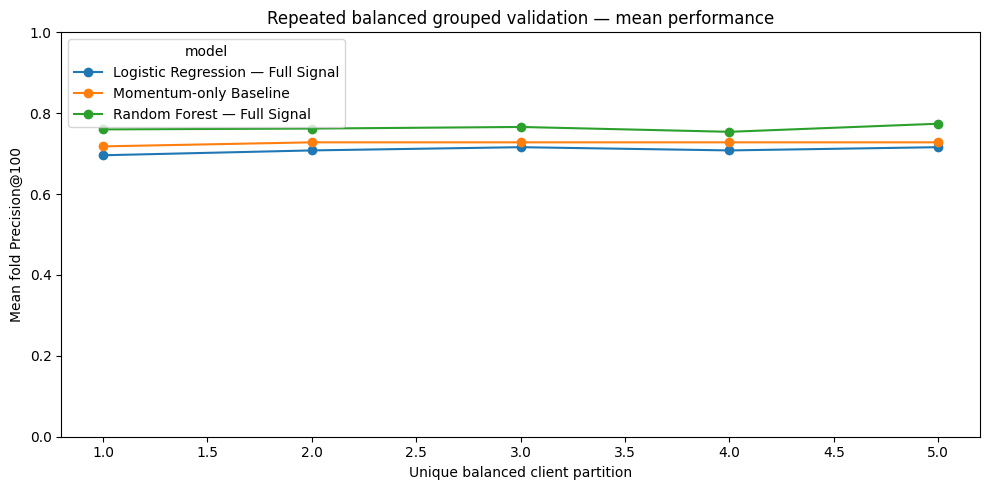

In [20]:
repeat_plot = per_repeat.pivot(
    index="repeat",
    columns="model",
    values="mean_p100",
)

ax = repeat_plot.plot(marker="o", figsize=(10, 5))
ax.set_xlabel("Unique balanced client partition")
ax.set_ylabel("Mean fold Precision@100")
ax.set_title("Repeated balanced grouped validation — mean performance")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


/tmp/ipykernel_1645/1623154311.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


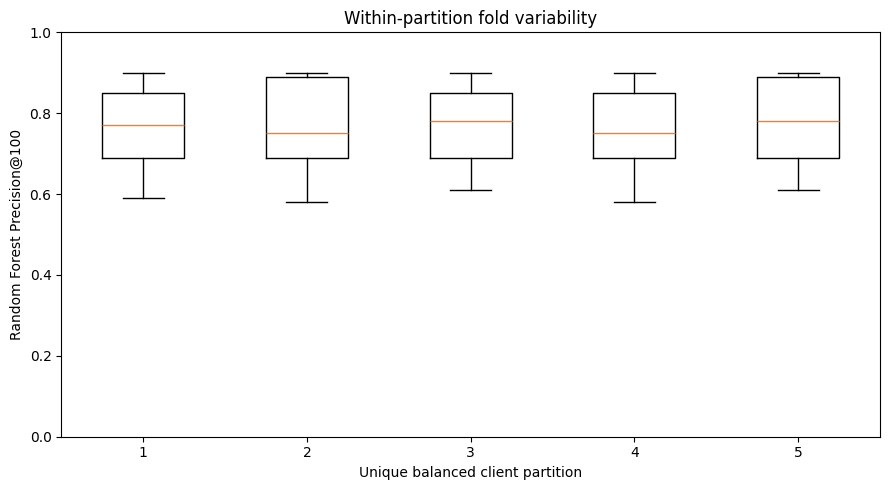

In [21]:
fig, ax = plt.subplots(figsize=(9, 5))

rf_fold_values = [
    group["precision_at_100"].to_numpy()
    for _, group in repeated_results[
        repeated_results["model"] == "Random Forest — Full Signal"
    ].groupby("repeat")
]

ax.boxplot(
    rf_fold_values,
    labels=[str(i) for i in range(1, len(rf_fold_values) + 1)],
)
ax.set_xlabel("Unique balanced client partition")
ax.set_ylabel("Random Forest Precision@100")
ax.set_title("Within-partition fold variability")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


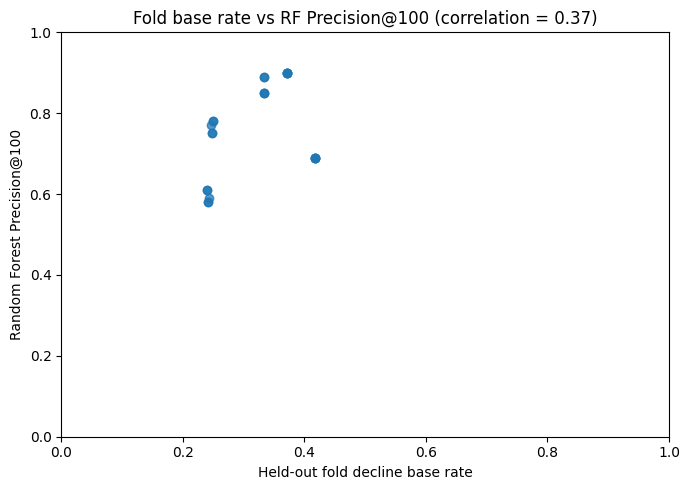

Correlation is descriptive, not causal: 0.369


In [22]:
rf_folds = repeated_results[
    repeated_results["model"] == "Random Forest — Full Signal"
].copy()

corr = rf_folds["base_rate"].corr(rf_folds["precision_at_100"])

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(
    rf_folds["base_rate"],
    rf_folds["precision_at_100"],
    alpha=0.75,
)
ax.set_xlabel("Held-out fold decline base rate")
ax.set_ylabel("Random Forest Precision@100")
ax.set_title(
    f"Fold base rate vs RF Precision@100 (correlation = {corr:.2f})"
)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

print("Correlation is descriptive, not causal:", f"{corr:.3f}")


## 16. Is the instability concentrated in particular clients?

Balanced folds fix the **number of clients per fold**, but they cannot make clients identical.

To look directly at client heterogeneity, each client receives an out-of-fold Precision@10 once per repeat.

We then summarize, for each client:

- mean RF P@10 across repeats;
- standard deviation across repeats;
- mean Momentum P@10;
- paired RF-minus-Momentum difference.

For public-safe display, raw pseudonymous IDs are replaced with local labels such as `Client 01`.


In [23]:
if repeated_client_metrics.empty:
    raise RuntimeError("No clients had enough pages for macro Precision@10.")

client_ids = sorted(
    repeated_client_metrics["client_id"].astype(str).unique().tolist()
)
client_label_map = {
    client_id: f"Client {i:02d}"
    for i, client_id in enumerate(client_ids, start=1)
}

client_safe = repeated_client_metrics.copy()
client_safe["client_label"] = (
    client_safe["client_id"].astype(str).map(client_label_map)
)

client_model_summary = (
    client_safe
    .groupby(["client_label", "model"], as_index=False)
    .agg(
        repeats=("repeat", "nunique"),
        mean_client_p10=("client_p_at_k", "mean"),
        sd_client_p10=("client_p_at_k", "std"),
        mean_client_base_rate=("client_base_rate", "mean"),
    )
)

client_p10_pivot = client_model_summary.pivot(
    index="client_label",
    columns="model",
    values="mean_client_p10",
)

client_sd_pivot = client_model_summary.pivot(
    index="client_label",
    columns="model",
    values="sd_client_p10",
)

client_heterogeneity = pd.DataFrame({
    "rf_mean_p10": client_p10_pivot["Random Forest — Full Signal"],
    "rf_sd_p10": client_sd_pivot["Random Forest — Full Signal"],
    "momentum_mean_p10": client_p10_pivot["Momentum-only Baseline"],
    "client_base_rate": (
        client_model_summary[
            client_model_summary["model"] == "Random Forest — Full Signal"
        ]
        .set_index("client_label")["mean_client_base_rate"]
    ),
}).dropna()

client_heterogeneity["rf_minus_momentum_pp"] = (
    client_heterogeneity["rf_mean_p10"]
    - client_heterogeneity["momentum_mean_p10"]
) * 100.0

print("Client-level heterogeneity summary:")
display(client_heterogeneity.describe().T)

print("Hardest clients for RF by repeated mean P@10:")
display(
    client_heterogeneity
    .sort_values("rf_mean_p10")
    .head(10)
    .style.format({
        "rf_mean_p10": "{:.1%}",
        "rf_sd_p10": "{:.1%}",
        "momentum_mean_p10": "{:.1%}",
        "client_base_rate": "{:.1%}",
        "rf_minus_momentum_pp": "{:+.1f}",
    })
)

print("Strongest clients for RF by repeated mean P@10:")
display(
    client_heterogeneity
    .sort_values("rf_mean_p10", ascending=False)
    .head(10)
    .style.format({
        "rf_mean_p10": "{:.1%}",
        "rf_sd_p10": "{:.1%}",
        "momentum_mean_p10": "{:.1%}",
        "client_base_rate": "{:.1%}",
        "rf_minus_momentum_pp": "{:+.1f}",
    })
)


Client-level heterogeneity summary:


,count,mean,std,min,25%,50%,75%,max
rf_mean_p10,24.0,0.693333,0.245917,0.100000,0.600000,0.740000,0.845000,1.000000
rf_sd_p10,24.0,0.017540,0.031358,0.000000,0.000000,0.000000,0.044721,0.122474
momentum_mean_p10,24.0,0.616667,0.264849,0.100000,0.475000,0.600000,0.825000,1.000000
client_base_rate,24.0,0.339569,0.134003,0.071429,0.280152,0.328834,0.422702,0.583333
rf_minus_momentum_pp,24.0,7.666667,17.028535,-30.000000,0.000000,10.000000,16.500000,44.000000


Hardest clients for RF by repeated mean P@10:


,rf_mean_p10,rf_sd_p10,momentum_mean_p10,client_base_rate,rf_minus_momentum_pp
client_label,,,,,
Client 06,10.0%,0.0%,10.0%,26.8%,+0.0
Client 15,10.0%,0.0%,10.0%,7.1%,+0.0
Client 01,30.0%,0.0%,30.0%,10.9%,+0.0
Client 07,50.0%,0.0%,80.0%,42.0%,-30.0
Client 16,60.0%,12.2%,40.0%,32.5%,+20.0
Client 13,60.0%,0.0%,50.0%,21.8%,+10.0
Client 11,60.0%,0.0%,50.0%,18.2%,+10.0
Client 18,60.0%,0.0%,70.0%,33.8%,-10.0
Client 05,68.0%,4.5%,50.0%,28.4%,+18.0


Strongest clients for RF by repeated mean P@10:


,rf_mean_p10,rf_sd_p10,momentum_mean_p10,client_base_rate,rf_minus_momentum_pp
client_label,,,,,
Client 04,100.0%,0.0%,100.0%,57.4%,+0.0
Client 12,100.0%,0.0%,90.0%,37.2%,+10.0
Client 14,100.0%,0.0%,90.0%,33.3%,+10.0
Client 09,90.0%,0.0%,90.0%,30.7%,+0.0
Client 24,88.0%,4.5%,50.0%,37.5%,+38.0
Client 23,86.0%,5.5%,100.0%,18.8%,-14.0
Client 17,84.0%,5.5%,40.0%,30.0%,+44.0
Client 02,80.0%,0.0%,80.0%,58.3%,+0.0
Client 19,80.0%,0.0%,100.0%,45.7%,-20.0


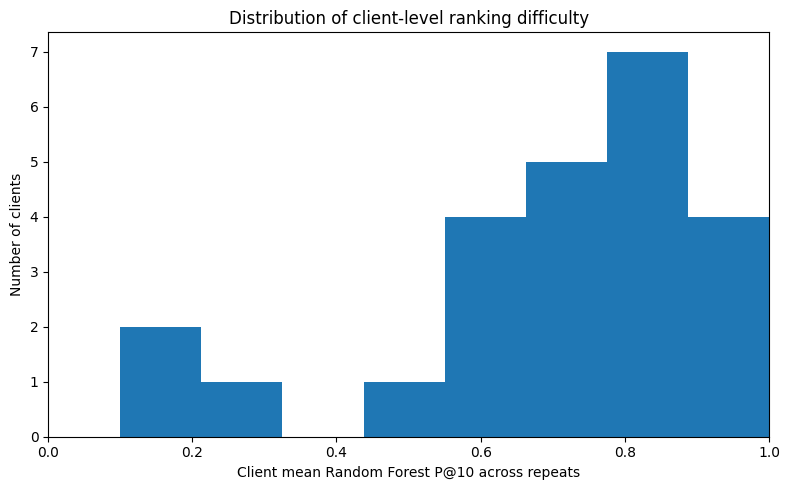

In [24]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(
    client_heterogeneity["rf_mean_p10"].dropna(),
    bins=min(10, max(5, len(client_heterogeneity) // 3)),
)
ax.set_xlabel("Client mean Random Forest P@10 across repeats")
ax.set_ylabel("Number of clients")
ax.set_title("Distribution of client-level ranking difficulty")
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()


## 17. Decision rule for the theory

We do **not** declare success from one attractive number.

Instead, compare:

- **between-repeat SD of the RF mean**;
- **mean within-repeat fold SD**;
- **client-level spread**;
- **paired RF-minus-Momentum delta across repeats**.

### Interpretation

**Case A — likely client heterogeneity**
- repeat means are relatively stable;
- individual folds remain volatile;
- some clients are consistently easier/harder.

Then the original fold swings are real deployment heterogeneity more than instability of the overall mean.

**Case B — partition-sensitive estimate**
- repeat means themselves move materially;
- RF-vs-Momentum delta changes sign often.

Then a single five-fold average is not a robust headline number.

**Case C — both**
- the overall mean moves somewhat;
- client-level differences are also large.

Then the capstone should report a range and emphasize uneven generalization across clients.

This notebook is a sensitivity analysis, not a new independent test set.


In [25]:
rf_sensitivity = sensitivity_summary[
    sensitivity_summary["model"] == "Random Forest — Full Signal"
].iloc[0]

rf_delta = delta_sensitivity[
    delta_sensitivity["model"] == "Random Forest — Full Signal"
].iloc[0]

between_sd = float(rf_sensitivity["between_repeat_sd"])
within_sd = float(rf_sensitivity["mean_within_repeat_sd"])

print("=" * 88)
print("REPEATED BALANCED VALIDATION — DECISION SUMMARY")
print("=" * 88)
print(
    f"Unique balanced partitions: {int(rf_sensitivity['repeats'])}"
)
print(
    "RF mean of repeat means: "
    f"{rf_sensitivity['mean_of_repeat_means']:.1%}"
)
print(
    "RF between-repeat SD of the mean: "
    f"{between_sd:.1%}"
)
print(
    "RF sensitivity range of repeat means: "
    f"{rf_sensitivity['min_repeat_mean']:.1%}–"
    f"{rf_sensitivity['max_repeat_mean']:.1%}"
)
print(
    "RF average within-repeat fold SD: "
    f"{within_sd:.1%}"
)
print(
    "RF mean paired delta vs Momentum: "
    f"{rf_delta['mean_delta_across_repeats_pp']:+.1f} pp"
)
print(
    "RF repeat wins / ties / losses vs Momentum: "
    f"{int(rf_delta['repeat_wins'])} / "
    f"{int(rf_delta['repeat_ties'])} / "
    f"{int(rf_delta['repeat_losses'])}"
)

print()
if np.isfinite(between_sd) and np.isfinite(within_sd) and within_sd > 0:
    ratio = between_sd / within_sd
    print(
        "Between-repeat SD / average within-repeat fold SD:",
        f"{ratio:.2f}",
    )

    if ratio < 0.5:
        print(
            "Diagnostic reading: the five-fold average is much more stable than "
            "the individual folds. This supports client heterogeneity as the main "
            "source of the visible fold swings."
        )
    else:
        print(
            "Diagnostic reading: the five-fold average also moves noticeably "
            "across valid balanced partitions. Treat the headline score as "
            "partition-sensitive and report the sensitivity range."
        )

print()
print(
    "Do not call this a confidence interval or independent replication. "
    "It is repeated sensitivity analysis on the same March cohort."
)


REPEATED BALANCED VALIDATION — DECISION SUMMARY
Unique balanced partitions: 5
RF mean of repeat means: 76.3%
RF between-repeat SD of the mean: 0.7%
RF sensitivity range of repeat means: 75.4%–77.4%
RF average within-repeat fold SD: 12.6%
RF mean paired delta vs Momentum: +3.7 pp
RF repeat wins / ties / losses vs Momentum: 5 / 0 / 0

Between-repeat SD / average within-repeat fold SD: 0.06
Diagnostic reading: the five-fold average is much more stable than the individual folds. This supports client heterogeneity as the main source of the visible fold swings.

Do not call this a confidence interval or independent replication. It is repeated sensitivity analysis on the same March cohort.


## 18. What to send back after **Run all**

Please send these outputs:

1. **Repeated balanced-client sensitivity summary**
2. **Paired lift vs Momentum across repeated balanced partitions**
3. **Decision summary**
4. The first two plots:
   - repeated mean performance;
   - RF within-partition fold variability

Those outputs are enough to decide whether the large fold swings mainly reflect:

- one unlucky balanced partition,
- persistent client heterogeneity,
- or instability in the headline estimate itself.

### Validation checklist

Before trusting the result:

- confirm the notebook generated multiple **unique partition hashes**;
- confirm every fold has about the same number of clients;
- confirm train/test client sets are disjoint;
- confirm the leakage guard passes;
- confirm the notebook is run top-to-bottom in one clean Colab session.

The notebook never prints the Hugging Face token and does not print raw client IDs in the final client-level diagnostics.
